# 01. CZ gate validation and error budget

这个 notebook 整合以下脚本：

- `run_cz_simulation.py`：最小 CZ gate fidelity 示例。
- `verify_cz_dark.py`：dark-detuning TO gate 的相位结构、leakage、dark/bright 对比。
- `plot_population_evolution_sch.py`：12 个 SSS 初态的 Schrodinger population evolution。
- `error_deterministic.py`：逐个打开 deterministic error source，做 XYZ/AL/LG 分解。
- `error_monte_carlo.py`：detuning noise、position noise、all errors 的 Monte Carlo branching。
- `generate_si_tables.py`：把 deterministic 和 MC 结果合成 SI 风格表格。
- `sensitivity_gaussian_iso.py`：高级参数敏感性和 iso-fidelity surface 分解。

整体逻辑是：先确认理想/优化 CZ gate 本身是对的，再看 population dynamics，最后把误差按物理来源拆开。这样可以区分“gate protocol 不对”和“物理误差源导致 infidelity”。


## 0. Notebook setup

这个 block 只做运行环境准备：定位 repo root，把 `src/` 加到 `sys.path`，并强制 JAX 使用 CPU。预期结果是后续 cell 可以直接导入 `ryd_gate`。这里不再依赖 `scripts/system_builders.py`，所有 system 都直接用 `RydbergSystem.from_lattice(...)` 构造；这样删除脚本后 notebook 仍然自洽。


In [2]:
from pathlib import Path
import os
import sys
import json

os.environ.setdefault("JAX_PLATFORMS", "cpu")

HERE = Path.cwd().resolve()
if HERE.name == "notebooks":
    REPO_ROOT = HERE.parents[1]
elif HERE.name == "scripts":
    REPO_ROOT = HERE.parent
else:
    REPO_ROOT = HERE
os.chdir(REPO_ROOT)

src_path = REPO_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, IFrame
from scipy.optimize import curve_fit

from ryd_gate import RydbergSystem
from ryd_gate.lattice import Register
from ryd_gate.analysis.gate_metrics import (
    average_gate_infidelity,
    sss_infidelity,
    population_evolution,
    state_infidelity,
    error_budget,
    residuals_to_branching,
)
from ryd_gate.backends.exact import simulate, MonteCarloResult, MonteCarloRunner
from ryd_gate.protocols.gate_cz import ARProtocol
from ryd_gate.protocols.gate_cz import TOProtocol

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
print(f"Repo root: {REPO_ROOT}")


Repo root: /home/chance/Ryd-gate-modeling


优化门参数

In [ ]:
# TO-parameter re-optimization on the current kernel API.
# Optimization workflows live in scripts/ (see scripts/optimize_ar_cz.py for the
# AR analogue); this cell keeps the inline TO variant. Flip the flag to re-run —
# a full Nelder-Mead search costs hours of exact-solver time.
RUN_TO_OPTIMIZATION = False

x0 = [
    0.6246672641243727,
    1.2369507331752663,
    -0.470787497434612,
    1.6547386752699043,
    3.41960305947842,
    1.3338111168065905,
]

if RUN_TO_OPTIMIZATION:
    from scipy.optimize import minimize

    system_opt = RydbergSystem.from_lattice(
        Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our",
        blackmanflag=True, detuning_sign=-1,
    )
    protocol_opt = TOProtocol()
    print("initial:", average_gate_infidelity(system_opt, protocol_opt, x0))
    res = minimize(
        lambda x: float(average_gate_infidelity(system_opt, protocol_opt, list(x))),
        x0, method="Nelder-Mead", options={"fatol": 1e-9, "disp": True},
    )
    print(res.fun)
    print(res.x.tolist())
else:
    print("Skipped TO re-optimization (set RUN_TO_OPTIMIZATION=True to run).")


## 1. Baseline CZ gate fidelity

这个 block 对应 `run_cz_simulation.py`。我们先计算 TO 和 AR 两类 CZ protocol 的 average gate infidelity。预期结果是 TO dark 参数的 infidelity 很小；这一步只回答“在没有打开误差预算之前，优化参数是否能实现高保真 CZ”。物理意义是把 control waveform 本身和后面要讨论的 spontaneous decay、position noise 等误差分离开。


In [3]:
# Optimized TO parameters used consistently in this notebook.
# x = [A, omega/Omega_eff, phi0, delta/Omega_eff, theta, T/T_scale]
X_TO_DARK = [
    -0.6989301339711643,
    1.0296229082590798,
    0.3759232324550267,
    1.5710180991068543,
    1.4454279613697887,
    1.3406239758422793,
]
X_TO_BRIGHT = [
    0.6246672641243727,
    1.2369507331752663,
    -0.470787497434612,
    1.6547386752699043,
    3.41960305947842,
    1.3338111168065905,
]
X_AR = [0.85973359, 0.39146974, 0.99181418, 0.1924498, -1.17123748, -0.00826712, 1.67429728, 0.28527346]

protocol_to = TOProtocol()
protocol_ar = ARProtocol()

system_dark = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1)
system_bright = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=-1)
system_plain = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our")

rows = []
rows.append(("TO", "dark detuning", average_gate_infidelity(system_dark, protocol_to, X_TO_DARK)))
rows.append(("TO", "bright detuning", average_gate_infidelity(system_bright, protocol_to, X_TO_BRIGHT)))
rows.append(("AR", "plain our system", average_gate_infidelity(system_plain, protocol_ar, X_AR)))

text = "| protocol | system | average infidelity |\n|---|---:|---:|\n"
for proto, label, val in rows:
    text += f"| {proto} | {label} | {val:.6e} |\n"
display(Markdown(text))


| protocol | system | average infidelity |
|---|---:|---:|
| TO | dark detuning | 7.803243e-07 |
| TO | bright detuning | 5.267349e-01 |
| AR | plain our system | 5.764713e-01 |


## 2. Dark-detuning CZ phase structure

这个 block 对应 `verify_cz_dark.py` 的核心检查。我们令 `theta=0` 先看 raw evolution：四个 computational basis state 应该基本回到自己，只积累相位。随后把 single-qubit Z phase `theta` 扣掉，`|11>` 相对 `|00>` 应该多出接近 `π` 的 CZ 相位。预期结果：population leakage 很小，`|CZ phase|-π` 很小。物理意义是确认该 pulse 真的实现 controlled phase，而不只是某个平均 fidelity 数字看起来好。


In [3]:
theta = X_TO_DARK[4]
x_no_theta = list(X_TO_DARK)
x_no_theta[4] = 0.0

basis = {label: system_dark.product_state(label) for label in ("00", "01", "10", "11")}
compiled_system = system_dark.with_protocol(protocol_to)

overlaps = {}
phase_rows = []
for label, psi0 in basis.items():
    psi_f = simulate(compiled_system, x_no_theta, psi0).psi_final
    overlap = np.vdot(psi0, psi_f)
    overlaps[label] = overlap

    comp_pop = 0.0
    for other in basis.values():
        comp_pop += abs(np.vdot(other, psi_f)) ** 2
    leakage = 1.0 - comp_pop
    phase_rows.append((label, abs(overlap) ** 2, np.angle(overlap), leakage))

phi00 = np.angle(overlaps["00"])
phi01 = np.angle(overlaps["01"])
phi10 = np.angle(overlaps["10"])
phi11 = np.angle(overlaps["11"])
cz_phase = phi11 - 2 * theta - phi00
cz_phase = (cz_phase + np.pi) % (2 * np.pi) - np.pi

text = "| input | return probability | raw phase (rad) | leakage |\n|---|---:|---:|---:|\n"
for label, pop, phase, leakage in phase_rows:
    text += f"| `{label}` | {pop:.10f} | {phase:+.6f} | {leakage:.3e} |\n"
text += "\n"
text += f"Single-qubit Z theta = `{theta:.6f}` rad.  \n"
text += f"CZ phase after removing Z rotations = `{cz_phase:+.6f}` rad.  \n"
text += f"Distance from ±π = `{abs(abs(cz_phase) - np.pi):.4e}` rad."
display(Markdown(text))


| input | return probability | raw phase (rad) | leakage |
|---|---:|---:|---:|
| `00` | 1.0000000000 | +2.724094 | 0.000e+00 |
| `01` | 0.9999992464 | -2.112920 | 7.536e-07 |
| `10` | 0.9999992464 | -2.112920 | 7.536e-07 |
| `11` | 0.9999990959 | +2.474685 | 9.041e-07 |

Single-qubit Z theta = `1.445428` rad.  
CZ phase after removing Z rotations = `-3.140265` rad.  
Distance from ±π = `1.3275e-03` rad.

## 3. SSS population evolution under the Schrodinger solver

这个 block 对应 `plot_population_evolution_sch.py`。我们对 12 个 SSS 初态分别跑 population evolution，并把 intermediate population、目标 Rydberg population、garbage Rydberg population 画出来。预期结果是 intermediate population 只在 pulse 中短暂出现，最终泄漏和 garbage Rydberg population 很小。物理意义是检查高 fidelity 背后的瞬态通道：如果 intermediate population 很高，后面的 intermediate decay budget 就会变大。


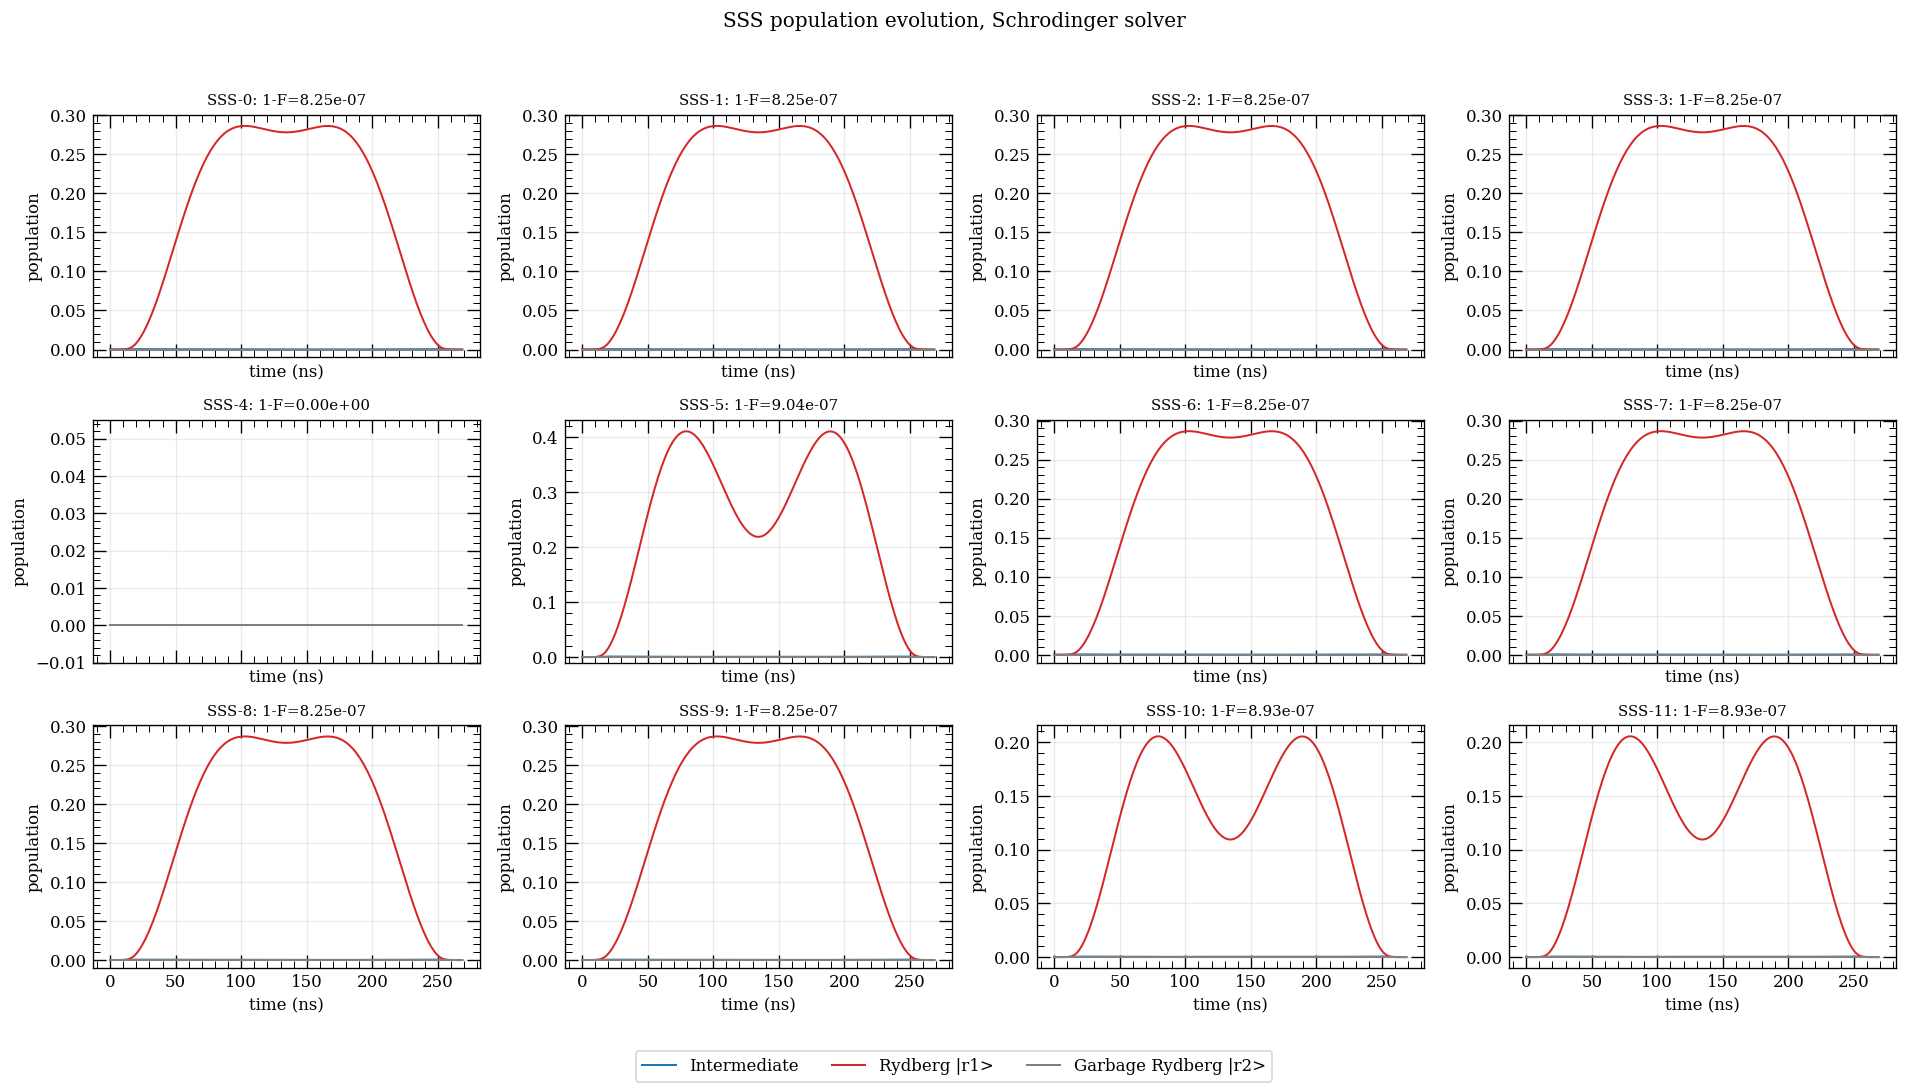

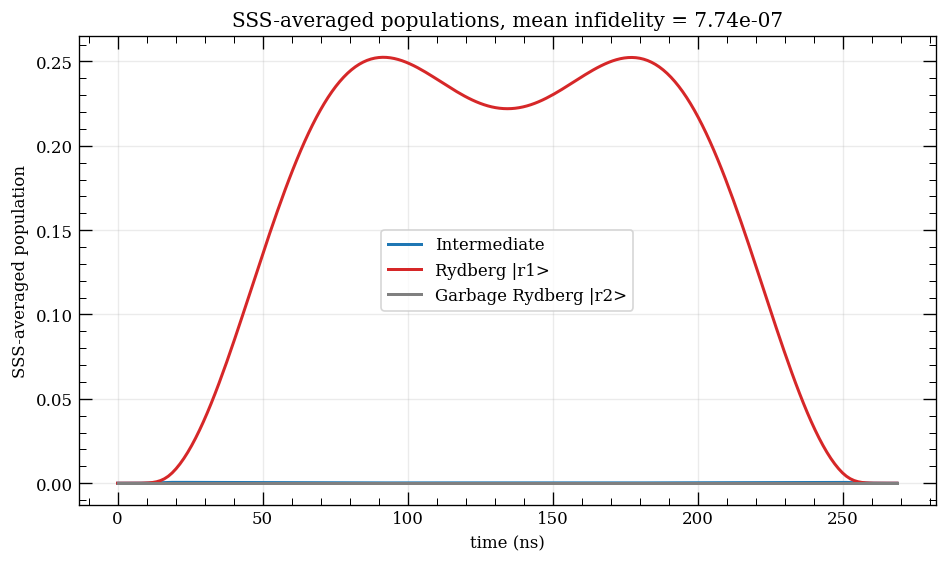

In [4]:
N_SSS = 12
categories = ["Intermediate", "Rydberg |r1>", "Garbage Rydberg |r2>"]
colors = {"Intermediate": "tab:blue", "Rydberg |r1>": "tab:red", "Garbage Rydberg |r2>": "gray"}

# population_evolution returns the times the exact backend actually recorded (the sparse
# piecewise backend stores one point per protocol step), so size the arrays from the
# returned t_list rather than hardcoding the sample count.
results = [population_evolution(system_dark, protocol_to, X_TO_DARK, f"SSS-{i}") for i in range(N_SSS)]
time_ns = np.asarray(results[0]["t_list"]) * 1e9
N_TIME = time_ns.size
pops = np.zeros((N_SSS, 3, N_TIME))
infidelities = np.zeros(N_SSS)
for i, result in enumerate(results):
    pops[i, 0, :] = (result["e1"] + result["e2"] + result["e3"]) / 2.0
    pops[i, 1, :] = result["ryd"] / 2.0
    pops[i, 2, :] = result["ryd_garb"] / 2.0
    infidelities[i] = state_infidelity(system_dark, protocol_to, X_TO_DARK, f"SSS-{i}")

fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharex=True)
for i, ax in enumerate(axes.flat):
    for c, cat in enumerate(categories):
        ax.plot(time_ns, pops[i, c], lw=1.2, color=colors[cat], label=cat)
    ax.set_title(f"SSS-{i}: 1-F={infidelities[i]:.2e}", fontsize=9)
    ax.set_ylim(bottom=-0.01)
    ax.set_xlabel("time (ns)")
    ax.set_ylabel("population")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)
fig.suptitle("SSS population evolution, Schrodinger solver", y=0.995)
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
for c, cat in enumerate(categories):
    ax.plot(time_ns, pops[:, c, :].mean(axis=0), lw=1.8, color=colors[cat], label=cat)
ax.set_title(f"SSS-averaged populations, mean infidelity = {infidelities.mean():.2e}")
ax.set_xlabel("time (ns)")
ax.set_ylabel("SSS-averaged population")
ax.legend()
fig.tight_layout()
plt.show()


## 4. Deterministic error budget

这个 block 对应 `error_deterministic.py` 和 `generate_si_tables.py` 的 deterministic 部分。默认优先读取 `data/det_dark.json`，这样 notebook 打开后不用重复跑昂贵计算；如果缓存不存在，会直接按脚本逻辑重算。预期结果是得到 Rydberg decay、intermediate decay、polarization leakage 和 all deterministic 的 infidelity 与 XYZ/AL/LG 分解。物理意义是判断哪类不可逆过程主导 gate error。


In [5]:
USE_CACHED_DETERMINISTIC = True
SSS_12_STATES = [f"SSS-{i}" for i in range(12)]
det_path = REPO_ROOT / "data" / "det_dark.json"
if USE_CACHED_DETERMINISTIC and det_path.exists():
    text = det_path.read_text()
    json_lines = [line for line in text.splitlines() if not line.startswith("#")]
    det = json.loads("\n".join(json_lines))
    print(f"Loaded deterministic cache: {det_path}")
else:
    det = {}
    protocol = TOProtocol()

    system_ryd = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1, enable_rydberg_decay=True)
    budget_ryd = error_budget(system_ryd, protocol, X_TO_DARK, initial_states=SSS_12_STATES)
    det["rydberg_decay"] = {"infidelity": sss_infidelity(system_ryd, protocol, X_TO_DARK), **budget_ryd["rydberg_decay"]}

    system_mid = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1, enable_intermediate_decay=True)
    budget_mid = error_budget(system_mid, protocol, X_TO_DARK, initial_states=SSS_12_STATES)
    det["intermediate_decay"] = {"infidelity": sss_infidelity(system_mid, protocol, X_TO_DARK), **budget_mid["intermediate_decay"]}

    system_mid_no0 = RydbergSystem.from_lattice(
        Register.chain(2, spacing_um=3.0),
        "rb87_7",
        param_set="our",
        blackmanflag=True,
        detuning_sign=1,
        enable_intermediate_decay=True,
        enable_0_scattering=False,
    )
    det["scattering_0_extra_infidelity"] = max(
        0.0,
        det["intermediate_decay"]["infidelity"] - sss_infidelity(system_mid_no0, protocol, X_TO_DARK),
    )

    system_pol = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1, enable_polarization_leakage=True)
    budget_pol = error_budget(system_pol, protocol, X_TO_DARK, initial_states=SSS_12_STATES)
    det["polarization_leakage"] = {"infidelity": sss_infidelity(system_pol, protocol, X_TO_DARK), **budget_pol["polarization_leakage"]}

    system_all = RydbergSystem.from_lattice(
        Register.chain(2, spacing_um=3.0),
        "rb87_7",
        param_set="our",
        blackmanflag=True,
        detuning_sign=1,
        enable_rydberg_decay=True,
        enable_intermediate_decay=True,
        enable_polarization_leakage=True,
    )
    budget_all = error_budget(system_all, protocol, X_TO_DARK, initial_states=SSS_12_STATES)
    det["all_deterministic"] = {
        "infidelity": sss_infidelity(system_all, protocol, X_TO_DARK),
        "XYZ": budget_all["rydberg_decay"]["XYZ"] + budget_all["intermediate_decay"]["XYZ"] + budget_all["polarization_leakage"]["XYZ"],
        "AL": budget_all["rydberg_decay"]["AL"] + budget_all["intermediate_decay"]["AL"] + budget_all["polarization_leakage"]["AL"],
        "LG": budget_all["rydberg_decay"]["LG"] + budget_all["intermediate_decay"]["LG"] + budget_all["polarization_leakage"]["LG"],
    }

text = "| source | infidelity | XYZ | AL | LG | coherent/phase residual |\n|---|---:|---:|---:|---:|---:|\n"
for key in ("rydberg_decay", "intermediate_decay", "polarization_leakage", "all_deterministic"):
    e = det[key]
    xyz = e.get("XYZ")
    al = e.get("AL")
    lg = e.get("LG")
    if xyz is None:
        text += f"| {key} | {e['infidelity']:.6e} | - | - | - | - |\n"
    else:
        residual = e["infidelity"] - (xyz + al + lg)
        if key == "intermediate_decay" and "scattering_0_extra_infidelity" in det:
            residual -= det["scattering_0_extra_infidelity"]
        text += f"| {key} | {e['infidelity']:.6e} | {xyz:.6e} | {al:.6e} | {lg:.6e} | {residual:.6e} |\n"
if "scattering_0_extra_infidelity" in det:
    text += f"\nIntermediate `|0>` scattering extra infidelity: `{det['scattering_0_extra_infidelity']:.6e}`."
display(Markdown(text))


Loaded deterministic cache: /home/chance/Ryd-gate-modeling/data/det_dark.json


| source | infidelity | XYZ | AL | LG | coherent/phase residual |
|---|---:|---:|---:|---:|---:|
| rydberg_decay | 5.521083e-04 | 8.694386e-05 | 3.482160e-04 | 1.169165e-04 | 3.189524e-08 |
| intermediate_decay | 1.850410e-03 | 5.063159e-04 | 0.000000e+00 | 6.533187e-04 | 3.582410e-07 |
| polarization_leakage | 7.158679e-05 | 4.369242e-08 | 1.752348e-05 | 5.875475e-08 | 5.396087e-05 |
| all_deterministic | 2.475912e-03 | 5.939197e-04 | 3.741466e-04 | 7.713500e-04 | 7.364961e-04 |

Intermediate `|0>` scattering extra infidelity: `6.904172e-04`.

## 5. Monte Carlo noise and branching

这个 block 对应 `error_monte_carlo.py`。默认读取 `data/mc_dark_dephasing.txt`、`data/mc_dark_position.txt`、`data/mc_dark_all.txt`。如果需要重算，把 `RUN_MONTE_CARLO=True`。预期结果是 total infidelity 的均值/标准误，以及 XYZ、AL、LG、phase branch 的平均贡献。物理意义是把 quasi-static dephasing、position fluctuation 与 deterministic decay 放在同一误差语言下比较。


In [6]:
RUN_MONTE_CARLO = False
N_MC = 500
MC_SEED = 42
mc = {}

for key in ("dephasing", "position", "all"):
    path = REPO_ROOT / "data" / f"mc_dark_{key}.txt"
    if path.exists():
        mc[key] = MonteCarloResult.load_from_file(path)
        print(f"Loaded {key}: {path}")

if RUN_MONTE_CARLO:
    sigma_pos = (70e-9, 70e-9, 130e-9)
    protocol = TOProtocol()

    system_deph = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1)
    engine = MonteCarloRunner(system_deph.with_protocol(protocol), X_TO_DARK)
    engine.setup_detuning_noise(130e3)
    mc["dephasing"] = engine.run_gate_fidelity(n_shots=N_MC, seed=MC_SEED, compute_branching=True)

    system_pos = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1)
    engine = MonteCarloRunner(system_pos.with_protocol(protocol), X_TO_DARK)
    engine.setup_position_noise(sigma_pos)
    mc["position"] = engine.run_gate_fidelity(n_shots=N_MC, seed=MC_SEED + 1, compute_branching=True)

    system_all = RydbergSystem.from_lattice(
        Register.chain(2, spacing_um=3.0),
        "rb87_7",
        param_set="our",
        blackmanflag=True,
        detuning_sign=1,
        enable_rydberg_decay=True,
        enable_intermediate_decay=True,
        enable_polarization_leakage=True,
    )
    engine = MonteCarloRunner(system_all.with_protocol(protocol), X_TO_DARK)
    engine.setup_detuning_noise(130e3)
    engine.setup_position_noise(sigma_pos)
    mc["all"] = engine.run_gate_fidelity(n_shots=N_MC, seed=MC_SEED + 2, compute_branching=True)

if mc:
    def _fmt(v):
        return f"{v:.6e}" if v is not None else "—"
    text = "| scenario | shots | mean infidelity | SEM | XYZ | AL | LG | phase |\n|---|---:|---:|---:|---:|---:|---:|---:|\n"
    for key, result in mc.items():
        sem = result.std_infidelity / np.sqrt(result.n_shots)
        text += (
            f"| {key} | {result.n_shots} | {result.mean_infidelity:.6e} | {sem:.2e} | "
            f"{_fmt(result.mean_branch_XYZ)} | {_fmt(result.mean_branch_AL)} | "
            f"{_fmt(result.mean_branch_LG)} | {_fmt(result.mean_branch_phase)} |\n"
        )
    display(Markdown(text))
else:
    print("No MC cache found. Set RUN_MONTE_CARLO=True to generate results.")


Loaded dephasing: /home/chance/Ryd-gate-modeling/data/mc_dark_dephasing.txt
Loaded position: /home/chance/Ryd-gate-modeling/data/mc_dark_position.txt
Loaded all: /home/chance/Ryd-gate-modeling/data/mc_dark_all.txt


| scenario | shots | mean infidelity | SEM | XYZ | AL | LG | phase |
|---|---:|---:|---:|---:|---:|---:|---:|
| dephasing | 1000 | 1.942413e-03 | 8.83e-05 | — | — | — | — |
| position | 1000 | 4.623568e-07 | 2.18e-08 | — | — | — | — |
| all | 1000 | 4.487244e-03 | 9.62e-05 | — | — | — | — |


## 6. SI-style combined table inside the notebook

这个 block 对应 `generate_si_tables.py` 的 notebook 版本。脚本原本输出 PDF；这里直接显示 Markdown table，方便读者在 notebook 中检查 deterministic 和 MC 误差。预期结果是一个把 deterministic、stochastic 和 total combined errors 放在一起的表。物理意义是形成最终 error budget 摘要。


In [7]:
if "det" in globals() and "mc" in globals() and mc:
    def _fmt(v):
        return f"{v:.6e}" if v is not None else "—"
    text = "| group | source | infidelity | XYZ | AL | LG | coh/phase |\n|---|---|---:|---:|---:|---:|---:|\n"
    for key in ("rydberg_decay", "intermediate_decay", "polarization_leakage", "all_deterministic"):
        e = det[key]
        xyz, al, lg = e.get("XYZ"), e.get("AL"), e.get("LG")
        residual = e["infidelity"] - (xyz + al + lg) if xyz is not None else np.nan
        if key == "intermediate_decay" and "scattering_0_extra_infidelity" in det:
            residual -= det["scattering_0_extra_infidelity"]
        text += f"| deterministic | {key} | {e['infidelity']:.6e} | {_fmt(xyz)} | {_fmt(al)} | {_fmt(lg)} | {_fmt(residual)} |\n"
    for key in ("dephasing", "position", "all"):
        if key not in mc:
            continue
        r = mc[key]
        text += (
            f"| Monte Carlo | {key} | {r.mean_infidelity:.6e} ± {r.std_infidelity / np.sqrt(r.n_shots):.2e} | "
            f"{_fmt(r.mean_branch_XYZ)} | {_fmt(r.mean_branch_AL)} | {_fmt(r.mean_branch_LG)} | {_fmt(r.mean_branch_phase)} |\n"
        )
    display(Markdown(text))
else:
    print("Run/load deterministic and MC blocks first.")


| group | source | infidelity | XYZ | AL | LG | coh/phase |
|---|---|---:|---:|---:|---:|---:|
| deterministic | rydberg_decay | 5.521083e-04 | 8.694386e-05 | 3.482160e-04 | 1.169165e-04 | 3.189524e-08 |
| deterministic | intermediate_decay | 1.850410e-03 | 5.063159e-04 | 0.000000e+00 | 6.533187e-04 | 3.582410e-07 |
| deterministic | polarization_leakage | 7.158679e-05 | 4.369242e-08 | 1.752348e-05 | 5.875475e-08 | 5.396087e-05 |
| deterministic | all_deterministic | 2.475912e-03 | 5.939197e-04 | 3.741466e-04 | 7.713500e-04 | 7.364961e-04 |
| Monte Carlo | dephasing | 1.942413e-03 ± 8.83e-05 | — | — | — | — |
| Monte Carlo | position | 4.623568e-07 ± 2.18e-08 | — | — | — | — |
| Monte Carlo | all | 4.487244e-03 ± 9.62e-05 | — | — | — | — |


## 7. Advanced: Gaussian sensitivity and iso-fidelity decomposition

这个 block 对应 `sensitivity_gaussian_iso.py`。这个分析非常耗时：脚本注释估计完整运行约数小时。因此默认关闭。打开后会按脚本顺序做三件事：单参数 Gaussian waist fit、sigma-normalized simultaneous sensitivity、iso-fidelity surface decomposition。物理意义是回答“优化点附近哪些 control 参数最敏感，以及误差增长后主要落到哪类 branch”。


In [8]:
RUN_LONG_SENSITIVITY = False

# This block is the notebook-native version of the former sensitivity script.
# It is intentionally linear rather than hidden behind helper functions: first
# sweep each pulse parameter, then use the fitted widths to probe simultaneous
# shifts and the iso-fidelity surface.
if RUN_LONG_SENSITIVITY:
    X_SENS = list(X_TO_DARK)
    PARAM_NAMES = {
        0: "A (cosine amplitude)",
        1: "omega/Omega_eff (mod. freq.)",
        2: "phi0 (initial phase)",
        3: "delta/Omega_eff (chirp rate)",
        5: "T/T_scale (gate time)",
    }
    PARAM_INDICES = [0, 1, 2, 3, 5]
    N_SWEEP_POINTS = 51
    INFIDELITY_CEILING = 0.01
    INITIAL_HALF_WIDTH_ABS = 0.02

    system_sens = RydbergSystem.from_lattice(
        Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1
    )
    protocol_sens = TOProtocol()
    baseline = average_gate_infidelity(system_sens, protocol_sens, X_SENS)
    print(f"Baseline average infidelity: {baseline:.4e}")

    sweep_results = {}
    sigmas = {}
    for idx in PARAM_INDICES:
        p_opt = X_SENS[idx]
        half_width = INITIAL_HALF_WIDTH_ABS
        for _ in range(20):
            x_plus = list(X_SENS)
            x_minus = list(X_SENS)
            x_plus[idx] = p_opt + half_width
            x_minus[idx] = p_opt - half_width
            inf_plus = average_gate_infidelity(system_sens, protocol_sens, x_plus)
            inf_minus = average_gate_infidelity(system_sens, protocol_sens, x_minus)
            if inf_plus >= INFIDELITY_CEILING and inf_minus >= INFIDELITY_CEILING:
                break
            half_width *= 2.0

        p_values = np.linspace(p_opt - half_width, p_opt + half_width, N_SWEEP_POINTS)
        infidelities = []
        for p_value in p_values:
            x = list(X_SENS)
            x[idx] = float(p_value)
            infidelities.append(average_gate_infidelity(system_sens, protocol_sens, x))
        infidelities = np.asarray(infidelities)
        fidelities = 1.0 - infidelities

        f_peak_guess = float(fidelities.max())
        p0_guess = float(p_values[np.argmax(fidelities)])
        threshold = f_peak_guess / np.e
        above = np.where(fidelities > threshold)[0]
        sigma_guess = (p_values[above[-1]] - p_values[above[0]]) / 2.0 if len(above) >= 2 else half_width / 3.0
        try:
            popt, pcov = curve_fit(
                lambda p, f_peak, p0, sigma: f_peak * np.exp(-((p - p0) ** 2) / (2 * sigma**2)),
                p_values,
                fidelities,
                p0=[f_peak_guess, p0_guess, max(sigma_guess, 1e-15)],
                bounds=([0.0, p_opt - half_width, 1e-15], [1.0 + 1e-10, p_opt + half_width, half_width * 3]),
                maxfev=10000,
            )
            fit_success = True
        except (RuntimeError, ValueError):
            popt = np.array([f_peak_guess, p0_guess, sigma_guess])
            fit_success = False
        sigma = abs(float(popt[2]))
        sigmas[idx] = sigma
        sweep_results[idx] = (p_values, infidelities, popt, fit_success)
        print(f"{PARAM_NAMES[idx]}: sigma={sigma:.8f}, p0_fit={popt[1]:.8f}, fit={'OK' if fit_success else 'fallback'}")

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for panel, idx in enumerate(PARAM_INDICES):
        ax = axes.flat[panel]
        p_values, infidelities, popt, fit_success = sweep_results[idx]
        fine = np.linspace(p_values[0], p_values[-1], 400)
        fit_infidelity = 1.0 - popt[0] * np.exp(-((fine - popt[1]) ** 2) / (2 * popt[2] ** 2))
        ax.semilogy(p_values, infidelities, "o", ms=3, label="simulation")
        ax.semilogy(fine, fit_infidelity, "r-", lw=1.2, label="Gaussian fit")
        ax.axvline(popt[1] - sigmas[idx], color="0.5", ls="--", lw=0.9)
        ax.axvline(popt[1] + sigmas[idx], color="0.5", ls="--", lw=0.9)
        ax.set_title(f"{PARAM_NAMES[idx]}\nsigma={sigmas[idx]:.4g}")
        ax.set_xlabel("parameter value")
        ax.set_ylabel("infidelity")
        ax.legend(fontsize=8)
    axes.flat[-1].set_visible(False)
    fig.suptitle("Per-parameter Gaussian sensitivity")
    fig.tight_layout()
    plt.show()

    sigma_arr = np.array([sigmas[idx] for idx in PARAM_INDICES])
    target = 0.001
    for sign, label in [(+1, "+alpha"), (-1, "-alpha")]:
        lo = 0.0
        hi = 0.001
        found = False
        for _ in range(60):
            x = list(X_SENS)
            for j, idx in enumerate(PARAM_INDICES):
                x[idx] += sign * hi * sigma_arr[j]
            if average_gate_infidelity(system_sens, protocol_sens, x) >= target:
                found = True
                break
            lo = hi
            hi *= 2.0
        if not found:
            print(f"{label}: no solution found up to alpha={hi:.3e}")
            continue
        for _ in range(60):
            mid = 0.5 * (lo + hi)
            x = list(X_SENS)
            for j, idx in enumerate(PARAM_INDICES):
                x[idx] += sign * mid * sigma_arr[j]
            if average_gate_infidelity(system_sens, protocol_sens, x) < target:
                lo = mid
            else:
                hi = mid
        alpha = 0.5 * (lo + hi)
        x = list(X_SENS)
        for j, idx in enumerate(PARAM_INDICES):
            x[idx] += sign * alpha * sigma_arr[j]
        print(f"{label}: alpha={alpha:.6e}, infidelity={average_gate_infidelity(system_sens, protocol_sens, x):.6e}")

    N_DIRECTIONS = 100
    ISO_FIDELITY_DROP = 0.001
    rng = np.random.default_rng(42)
    directions = rng.standard_normal((N_DIRECTIONS, len(PARAM_INDICES)))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)
    target_iso = baseline + ISO_FIDELITY_DROP
    decompositions = []
    alphas = []
    skipped = 0
    for i, direction in enumerate(directions):
        lo = 0.0
        hi = 0.1
        found = False
        for _ in range(30):
            x = list(X_SENS)
            for j, idx in enumerate(PARAM_INDICES):
                x[idx] += hi * sigma_arr[j] * direction[j]
            if average_gate_infidelity(system_sens, protocol_sens, x) >= target_iso:
                found = True
                break
            lo = hi
            hi *= 2.0
            if hi > 20.0:
                break
        if not found:
            skipped += 1
            continue
        for _ in range(25):
            mid = 0.5 * (lo + hi)
            x = list(X_SENS)
            for j, idx in enumerate(PARAM_INDICES):
                x[idx] += mid * sigma_arr[j] * direction[j]
            if average_gate_infidelity(system_sens, protocol_sens, x) < target_iso:
                lo = mid
            else:
                hi = mid
        alpha = 0.5 * (lo + hi)
        x = list(X_SENS)
        for j, idx in enumerate(PARAM_INDICES):
            x[idx] += alpha * sigma_arr[j] * direction[j]
        infidelity, residuals = average_gate_infidelity(system_sens, protocol_sens, x, return_residuals=True)
        branching = residuals_to_branching(system_sens, residuals)
        xyz = branching["XYZ"]
        al = branching["AL"]
        lg = branching["LG"]
        phase = max(infidelity - (xyz + al + lg), 0.0)
        total = max(xyz + al + lg + phase, 1e-300)
        decompositions.append((xyz / total, al / total, lg / total, phase / total, xyz, al, lg, phase))
        alphas.append(alpha)
        if (i + 1) % 50 == 0:
            print(f"{i + 1}/{N_DIRECTIONS} directions processed")

    if decompositions:
        decomp = np.asarray(decompositions)
        alphas = np.asarray(alphas)
        names = ["XYZ", "AL", "LG", "Phase"]
        means = decomp[:, :4].mean(axis=0)
        stds = decomp[:, :4].std(axis=0)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
        axes[0].bar(names, means, yerr=stds, capsize=4)
        axes[0].set_ylim(0, 1)
        axes[0].set_ylabel("fraction")
        axes[0].set_title("Mean error fractions on iso-fidelity surface")
        axes[1].hist(alphas, bins=30, color="steelblue", edgecolor="black")
        axes[1].set_xlabel("alpha (sigma units)")
        axes[1].set_title("Distance to iso-fidelity surface")
        axes[2].scatter(decomp[:, 1], decomp[:, 3], s=12, alpha=0.6)
        axes[2].set_xlabel("AL fraction")
        axes[2].set_ylabel("Phase fraction")
        axes[2].set_title("AL vs phase")
        fig.tight_layout()
        plt.show()
        print(f"surface points={len(decompositions)}, skipped={skipped}, alpha mean={alphas.mean():.4f}")
else:
    print("Skipped long sensitivity scan. Set RUN_LONG_SENSITIVITY=True to run the notebook-native analysis.")

# If older PDF outputs exist from previous runs, still embed them for convenience.
for pdf in (REPO_ROOT / "gaussian_waist_scan.pdf", REPO_ROOT / "iso_fidelity_decomposition.pdf"):
    if pdf.exists():
        display(Markdown(f"### Cached figure: {pdf.name}"))
        display(IFrame(str(pdf), width=900, height=650))


Skipped long sensitivity scan. Set RUN_LONG_SENSITIVITY=True to run the notebook-native analysis.
